# Module 5 · Lab 5.1 — Tool-Calling Agents & the ReAct Loop
## From a single tool to a reason–act–observe agent with `create_agent`

**Scenario.** A user asks a multi-faceted question: "What's 3.14 × 2.718? What's the weather in Mumbai? And what are the 4 major Agentic AI design patterns?". A single chain with one model can't answer all three — we need tools (math, weather, web search) and an LLM that picks the right one for each part.

**Learning Objectives.** By the end of this lab, you will be able to:
1. Use **built-in LangChain tools** (Tavily search) and inspect their schema.
2. Build **custom tools** with the `@tool` decorator (simple) and `StructuredTool` (with Pydantic-typed inputs).
3. Bind tools to a chat model and inspect the model's `tool_calls` output.
4. Construct a tool-calling agent with the LangChain v1 **`create_agent`** (replaces legacy `AgentExecutor`).
5. Debug tool-call failures — what to do when the agent picks the wrong tool, hits a tool exception, or loops.

**What we deliberately drop from the source notebook**
- Long Section 1 introduction and the Wikipedia tool demo (redundant — Tavily covers built-in-tool patterns).
- The `markitdown` web-extraction custom tool (heavy dependency, marginal pedagogical value).
- The non-native tool-calling section using prompt-based JSON (niche — every modern frontier model has native tool-calling). §8b keeps one compact version, because it shows the stop-sequence and parse-error mechanics that native tool calling hides.
- Manual tool-routing while-loops — replaced with `create_agent` (LangChain v1).

---


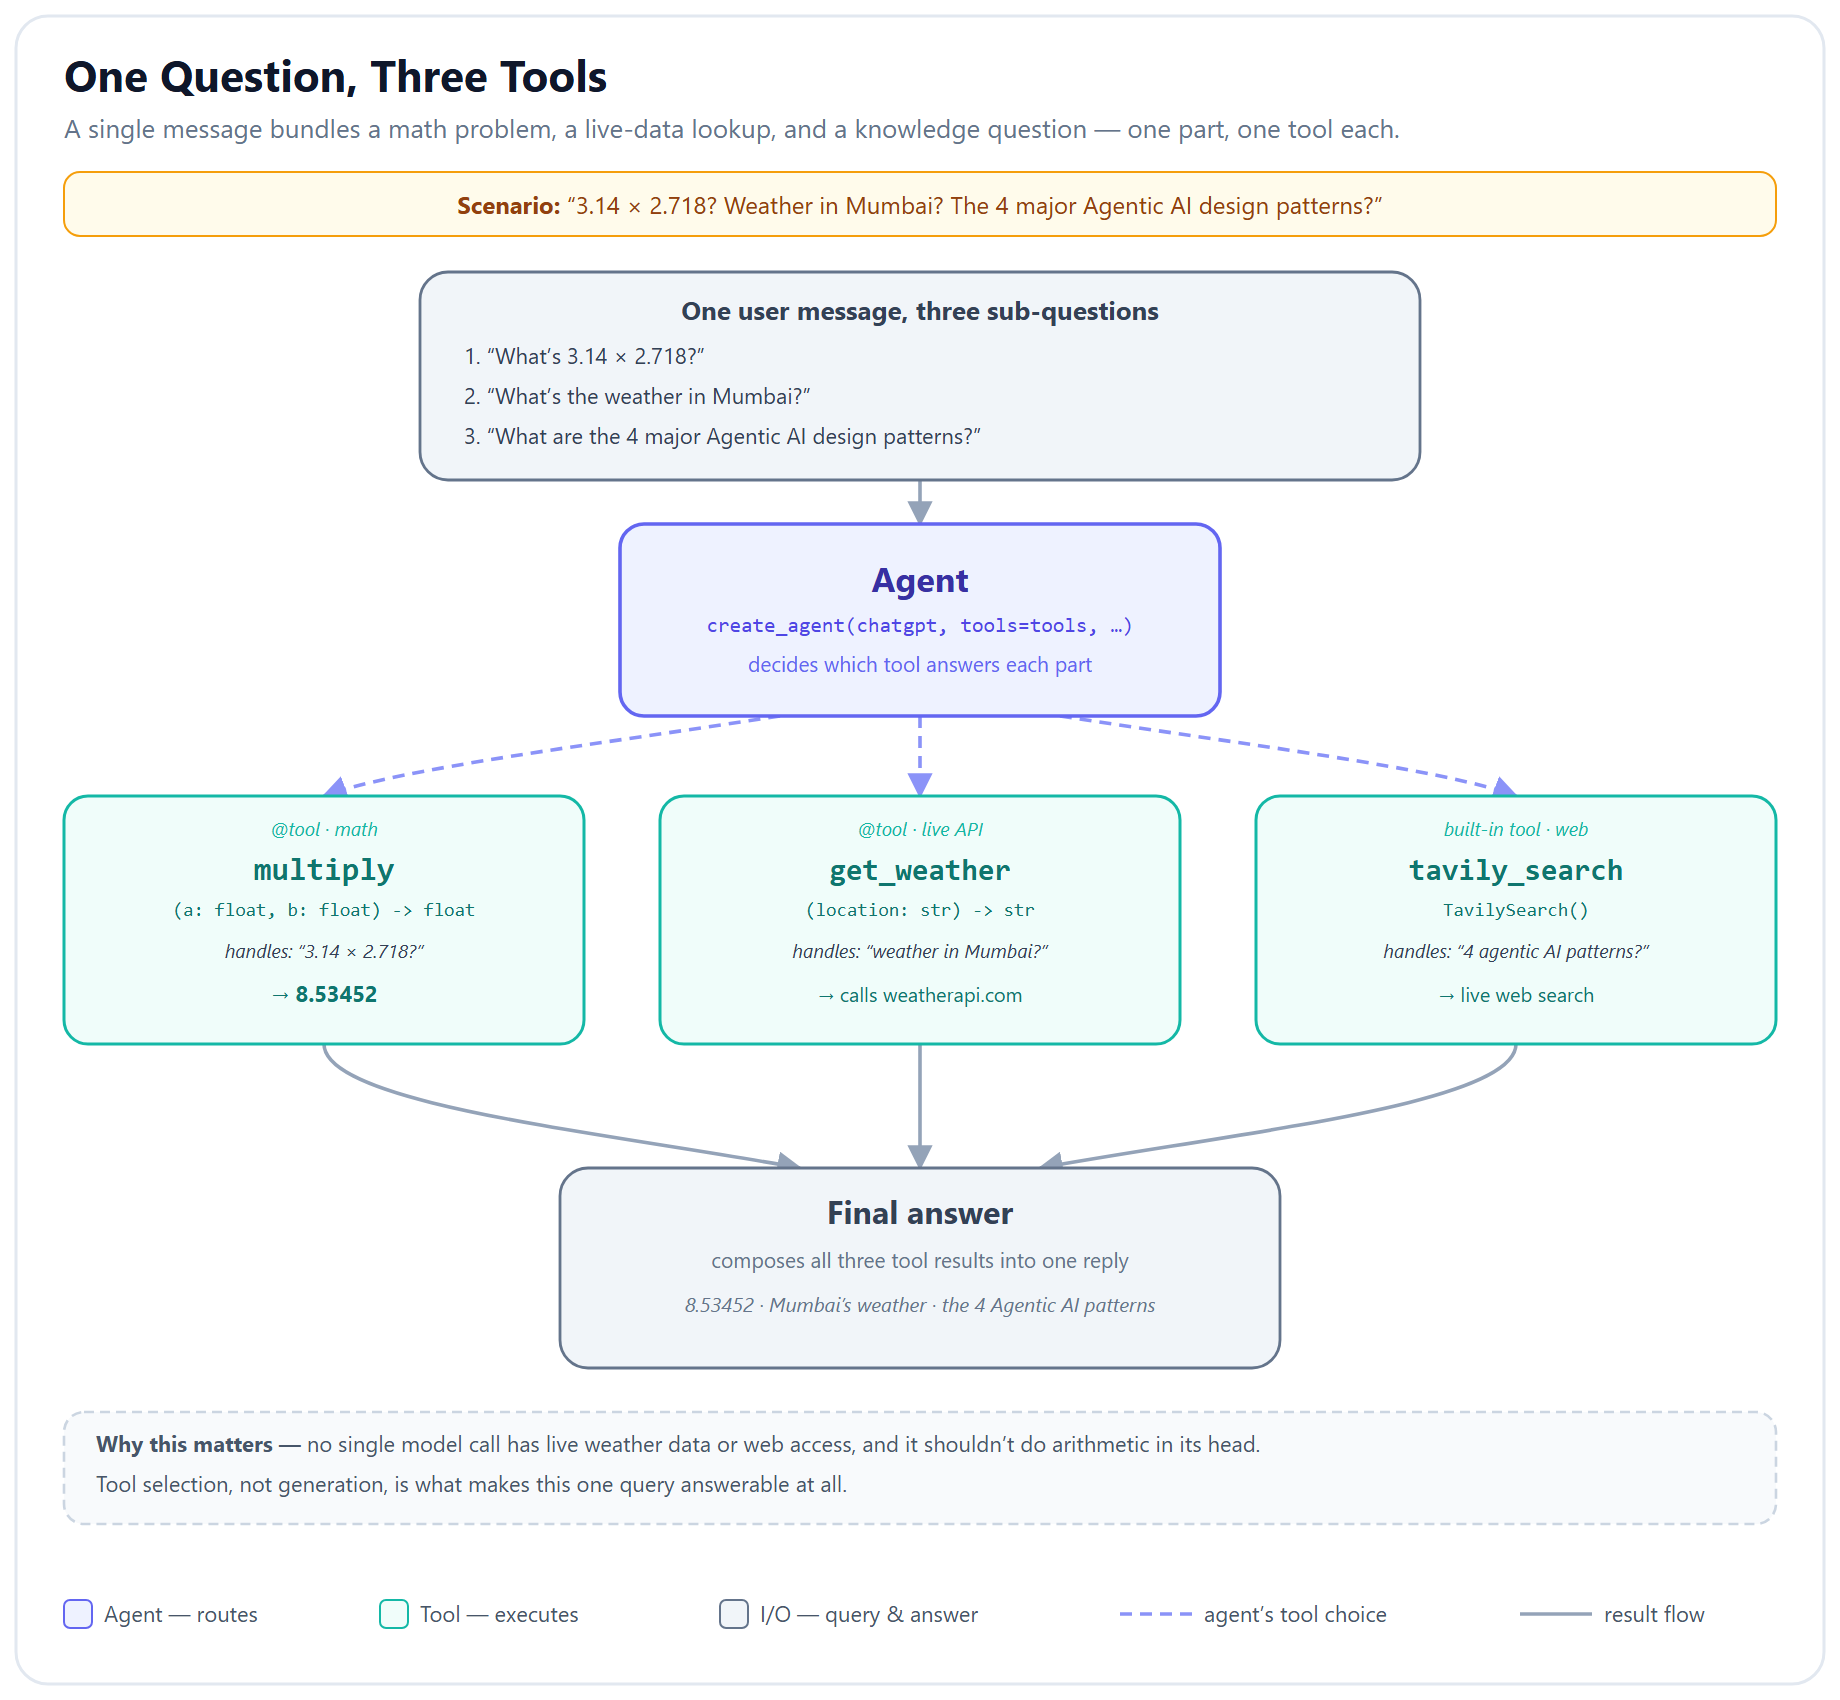

**Figure — One question, three tools.** The lab's scenario — *3.14 × 2.718? weather in Mumbai? the four agentic design patterns?* — needs three different tools. A tool-calling agent reasons about each part, routes it to `multiply` / `get_weather` / `tavily_search`, then composes one grounded final answer.

## 1. Install Dependencies

In [1]:
# 📦 Packages this notebook needs. On the workshop VM they are pre-installed from
# the workshop's requirements.txt, so the install line below stays commented out.
# Running somewhere else (Colab, your own laptop)? Uncomment it and run this cell once.
# !pip install -qU langchain langchain-core langchain-openai langchain-community langchain-tavily langchain-groq requests pydantic python-dotenv

from importlib.metadata import PackageNotFoundError, version

NOTEBOOK_PACKAGES = [
    "langchain",
    "langchain-core",
    "langchain-openai",
    "langchain-community",
    "langchain-tavily",
    "langchain-groq",
    "requests",
    "pydantic",
    "python-dotenv",
]
for package_name in NOTEBOOK_PACKAGES:
    try:
        print(f"{package_name:<26} {version(package_name)}")
    except PackageNotFoundError:
        print(f"{package_name:<26} NOT INSTALLED — uncomment the !pip line above")

langchain                  1.4.3
langchain-core             1.6.6
langchain-openai           1.6.6
langchain-community        0.4.2
langchain-tavily           0.2.18
langchain-groq             1.1.3
requests                   2.34.2
pydantic                   2.12.5
python-dotenv              1.2.3


## 2. API Key Configuration

This lab needs four keys: OpenAI (model), Tavily (web search), WeatherAPI (weather tool), and Groq (used for one comparison call). The trainer supplies OpenAI; the other three are free keys you create — the key cell tells you where.


In [2]:
import os

# Where to create each key. The trainer supplies OPENAI_API_KEY on the workshop VM;
# you create any other key yourself and add it to the workshop's .env file as KEY_NAME=value.
KEY_SIGNUP_PAGES = {
    "OPENAI_API_KEY": "supplied on the workshop VM (elsewhere: https://platform.openai.com/api-keys)",
    "TAVILY_API_KEY": "https://app.tavily.com (free tier)",
    "GROQ_API_KEY": "https://console.groq.com/keys (free tier)",
    "WEATHER_API_KEY": "https://www.weatherapi.com/signup.aspx (free tier)",
    "LANGSMITH_API_KEY": "https://smith.langchain.com -> Settings -> API Keys (free tier)",
    "ANTHROPIC_API_KEY": "https://console.anthropic.com/settings/keys",
    "GEMINI_API_KEY": "https://aistudio.google.com/app/apikey",
}


def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere).

    Prints one line per key, then stops with instructions if a required key is missing.

    Args:
        required: the environment-variable names this lab needs.
    """
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # the workshop VM, or any local machine
        from dotenv import find_dotenv, load_dotenv
        load_dotenv(find_dotenv(usecwd=True))        # searches upward for the workshop's .env file
        source = ".env / environment"
    print(f"\U0001F511 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")
    missing_keys = [key_name for key_name in required if not os.environ.get(key_name)]
    if missing_keys:
        instructions = "\n".join(
            f"  {key_name}: {KEY_SIGNUP_PAGES.get(key_name, 'see README.md in the workshop folder')}"
            for key_name in missing_keys)
        raise RuntimeError(
            "This lab needs API keys that are not set yet. Create each one, add it to\n"
            "the workshop's .env file as KEY_NAME=value, then re-run this cell:\n" + instructions)

# OPENAI → model · TAVILY → web search · WEATHER_API → weather tool · GROQ → provider comparison
load_keys(["OPENAI_API_KEY", "TAVILY_API_KEY", "WEATHER_API_KEY", "GROQ_API_KEY"])

🔑 Key source: .env / environment
   OPENAI_API_KEY         ✅
   TAVILY_API_KEY         ✅
   WEATHER_API_KEY        ✅
   GROQ_API_KEY           ✅


## 3. Imports & LLM Init


In [3]:
from langchain_openai import ChatOpenAI

# We use a non-reasoning model (gpt-4.1-mini) here — temperature=0 for deterministic tool selection.
# Reasoning models like gpt-5-mini also work for tool calling but spend extra tokens on thinking.
chatgpt = ChatOpenAI(model='gpt-4.1-mini', temperature=0)
print('LLM initialized:', chatgpt.model_name)


LLM initialized: gpt-4.1-mini


---

## 4. Built-in Tool — Tavily Web Search

LangChain ships with adapters for many web-search APIs. **Tavily** is purpose-built for LLM agents: it returns short structured snippets with full-content option, optimized for downstream prompts.


In [4]:
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=4,           # cap results for token budget
    search_depth='advanced', # 'basic' or 'advanced'
)

print('Tool name:', tavily_tool.name)
print('Description:', tavily_tool.description)
print('Args schema:', tavily_tool.args)


Tool name:

 tavily_search
Description: A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, accurate, and citation-backed results.Input should be a search query.
Args schema: {'query': {'description': 'Search query to look up', 'title': 'Query', 'type': 'string'}, 'include_domains': {'anyOf': [{'items': {'type': 'string'}, 'type': 'array'}, {'type': 'null'}], 'default': [], 'description': 'A list of domains to restrict search results to.\n\n        Use this parameter when:\n        1. The user explicitly requests information from specific websites (e.g., "Find climate data from nasa.gov")\n        2. The user mentions an organization or company without specifying the domain (e.g., "Find information about iPhones from Apple")\n\n        In both case

In [ ]:
# Direct invocation (without an LLM) — useful for testing
search_output = tavily_tool.invoke({'query': 'What are the major Agentic AI design patterns in 2026?'})
print(type(search_output).__name__)
if isinstance(search_output, dict) and 'results' in search_output:
    for search_result in search_output['results'][:2]:
        print('-', search_result.get('title', '')[:80])
        print(' ', (search_result.get('content') or '')[:200], '...')
else:
    print(str(search_output)[:400], '...')


---

## 5. Custom Tool with `@tool` — the Quick Form

The fastest way to define a tool: decorate any Python function. The function name becomes the tool name, the docstring becomes the description (the LLM reads it), the type hints become the schema.


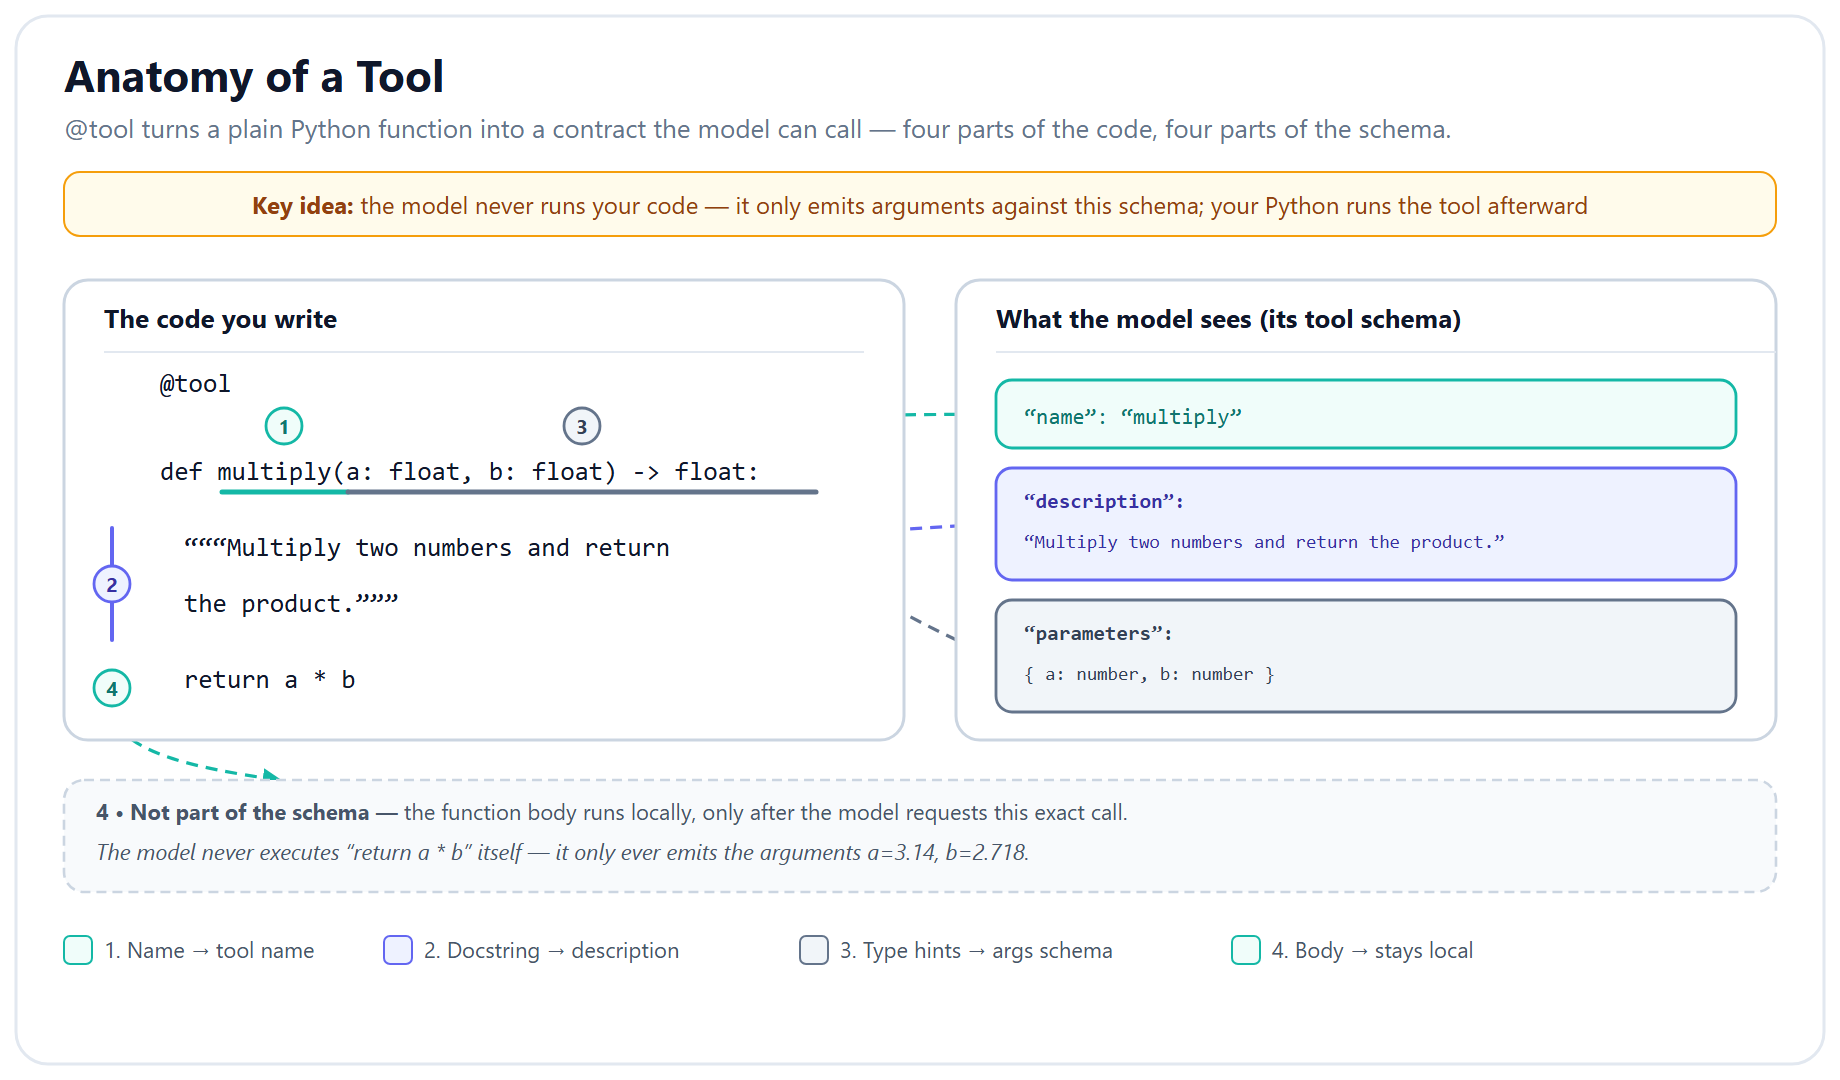

**Figure — Anatomy of a tool.** The function name becomes the tool name, the docstring becomes the description the model reads, and the type hints (or a Pydantic `args_schema`) become the JSON schema the model fills in — the model never runs your code, it only emits arguments against this contract.

In [6]:
from langchain_core.tools import tool

@tool
def multiply(first_number: float, second_number: float) -> float:
    """Multiply two numbers and return the product."""
    return first_number * second_number

# Inspect the auto-generated schema
print('name        :', multiply.name)
print('description :', multiply.description)
print('args        :', multiply.args)


name        : multiply
description : Multiply two numbers and return the product.
args        : {'first_number': {'title': 'First Number', 'type': 'number'}, 'second_number': {'title': 'Second Number', 'type': 'number'}}


In [7]:
# Direct invocation — the tool is just a Runnable under the hood
print(multiply.invoke({'first_number': 3.14, 'second_number': 2.718}))
print(multiply.invoke({'first_number': 7, 'second_number': 12}))


8.53452
84.0


---

## 6. Custom Tool with `StructuredTool` + Pydantic — the Strict Form

When you need **explicit field descriptions** (which the LLM reads to pick the right tool) or **stricter validation**, use `StructuredTool.from_function(...)` with a Pydantic `args_schema`.


In [8]:
from pydantic import BaseModel, Field
from langchain_core.tools import StructuredTool

class CalculatorInput(BaseModel):
    """The two numbers `multiply_strict` multiplies. Each `Field` description is shown to the model."""
    first_number: float = Field(description='The first number to multiply')
    second_number: float = Field(description='The second number to multiply')

def _multiply(first_number: float, second_number: float) -> float:
    """Multiply two numbers."""
    return first_number * second_number

multiply_strict = StructuredTool.from_function(
    func=_multiply,
    name='multiply_strict',
    description='Use to multiply two numbers. Both arguments must be numeric.',
    args_schema=CalculatorInput,
)

print('name        :', multiply_strict.name)
print('description :', multiply_strict.description)
print('args (with field descriptions):')
for argument_name, argument_schema in multiply_strict.args.items():
    print(f'  {argument_name}: {argument_schema}')


name        : multiply_strict
description : Use to multiply two numbers. Both arguments must be numeric.
args (with field descriptions):
  first_number: {'description': 'The first number to multiply', 'title': 'First Number', 'type': 'number'}
  second_number: {'description': 'The second number to multiply', 'title': 'Second Number', 'type': 'number'}


In [9]:
# Validation in action — passing a non-numeric raises pydantic.ValidationError
from pydantic import ValidationError

try:
    multiply_strict.invoke({'first_number': 3.14, 'second_number': 'abc'})
except ValidationError as error:
    print('Caught ValidationError:')
    print(error.errors()[0]['msg'])


Caught ValidationError:
Input should be a valid number, unable to parse string as a number


---

## 7. Custom Tool — Real-World API Call (Weather)

A tool that calls an external HTTP API. Same `@tool` pattern — the LLM doesn't care that this one hits the network.


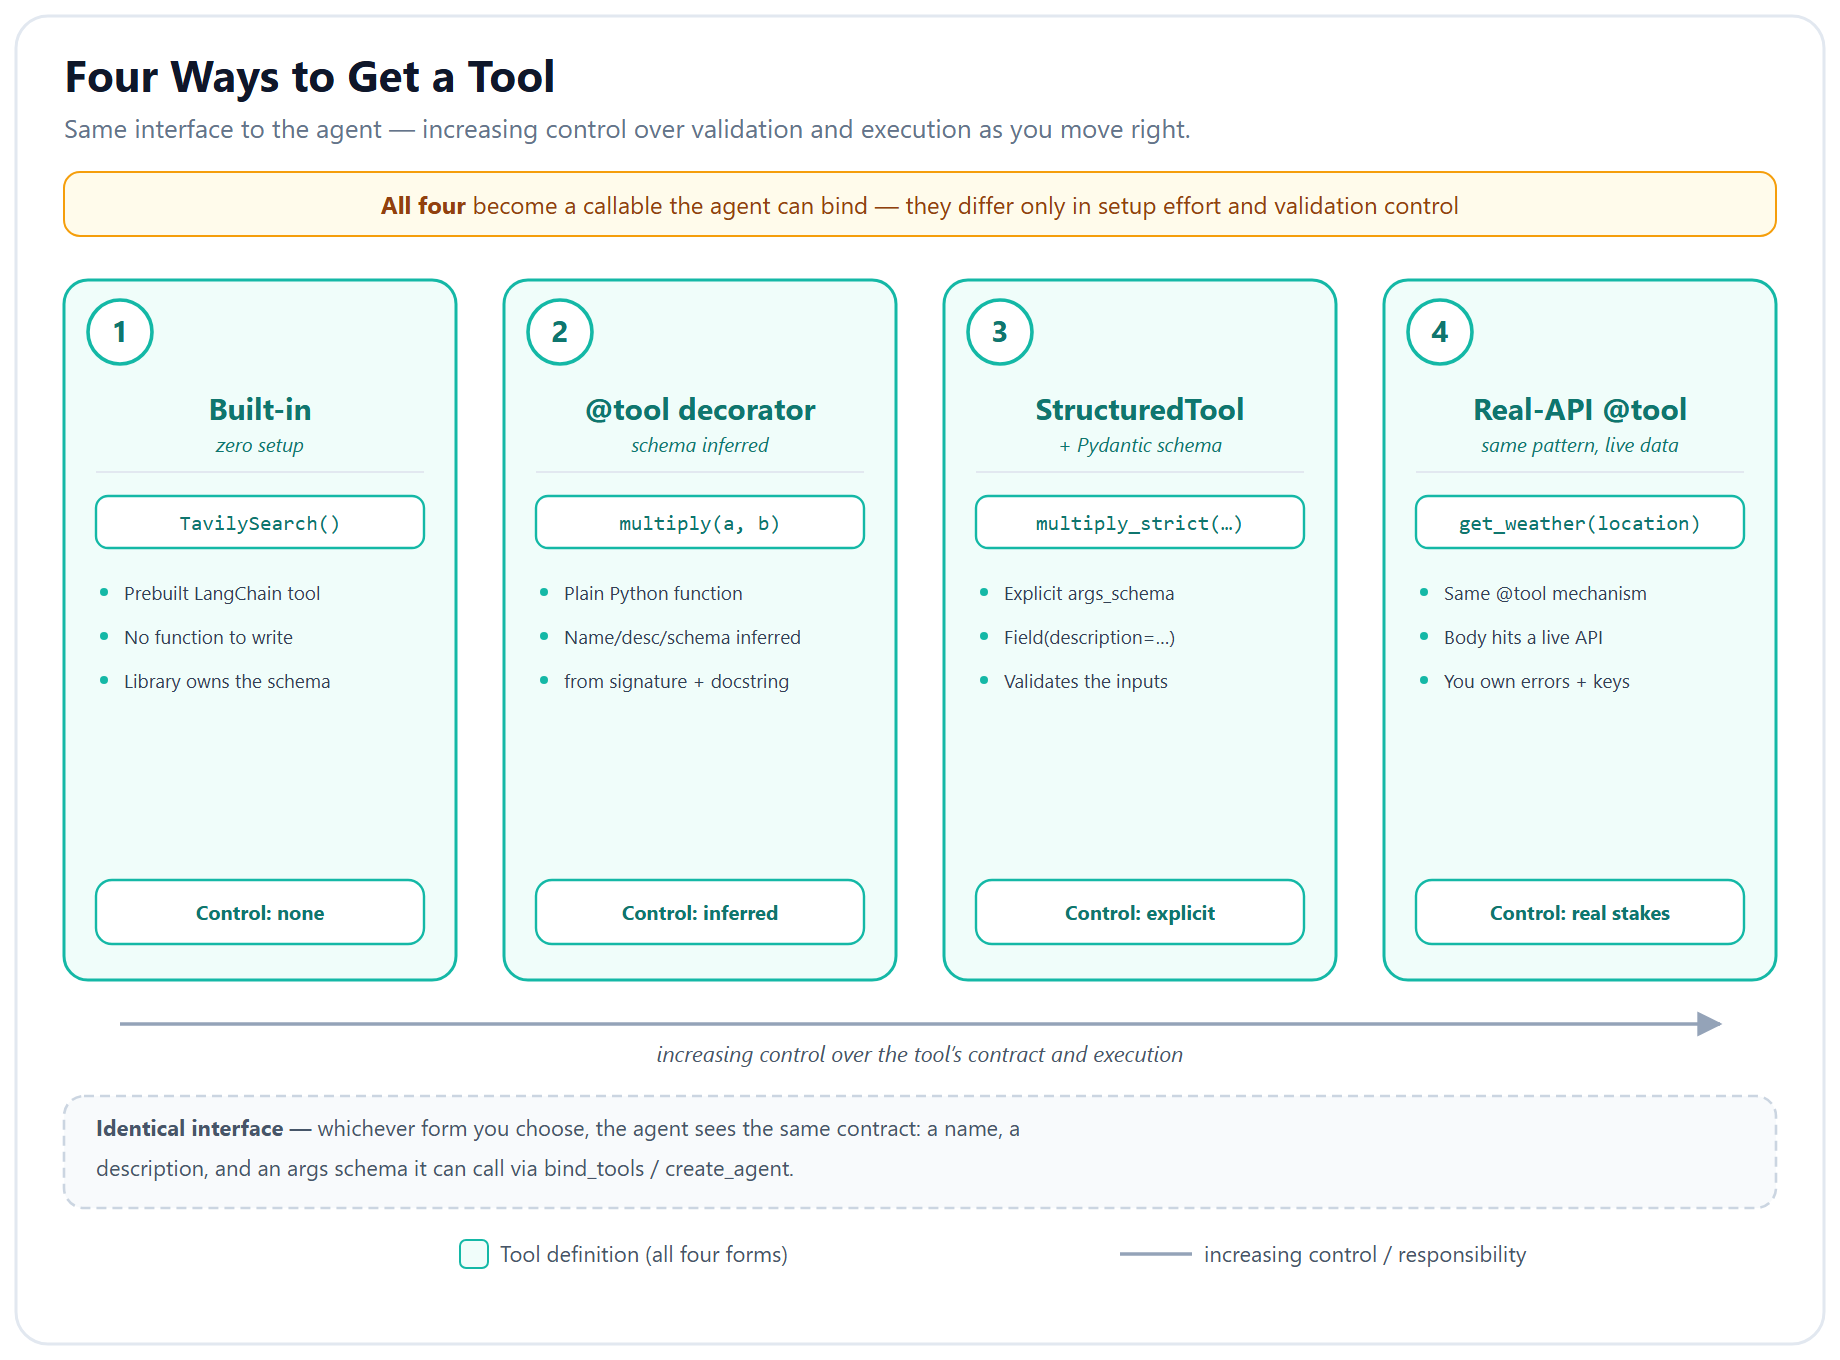

**Figure — Four ways to get a tool.** A built-in adapter (`TavilySearch`), the `@tool` decorator (schema inferred from type hints), `StructuredTool` + Pydantic (explicit `Field` descriptions and validation), and a `@tool` that calls a live HTTP API (`get_weather`) — increasing control, identical interface.

In [ ]:
import os
import requests
from langchain_core.tools import tool

@tool
def get_weather(location: str) -> dict:
    """Get the current weather for a city or location. Returns a dict with temperature, condition, and humidity."""
    api_key = os.environ.get('WEATHER_API_KEY')
    if not api_key:
        return {'error': 'WEATHER_API_KEY not set in environment'}

    request_url = f'https://api.weatherapi.com/v1/current.json?key={api_key}&q={location}'
    response = requests.get(request_url, timeout=10)
    if response.status_code != 200:
        return {'error': f'API returned {response.status_code}'}

    data = response.json()
    if 'location' not in data:
        return {'error': 'Location not found'}
    return {
        'location': data['location']['name'],
        'country': data['location']['country'],
        'temp_c': data['current']['temp_c'],
        'condition': data['current']['condition']['text'],
        'humidity': data['current']['humidity'],
    }

print(get_weather.invoke({'location': 'Mumbai'}))


---

## 8. Tool Calling — Manual Form with `bind_tools`

Before reaching for an agent, it helps to see what tool-calling looks like at the **model API level**. `llm.bind_tools(tools)` returns a chat model that — when asked something tool-related — produces a `tool_calls` list instead of plain text.

This is the building block; `create_agent` (next section) wraps the loop of "call tool, feed result back to model, repeat" around it.


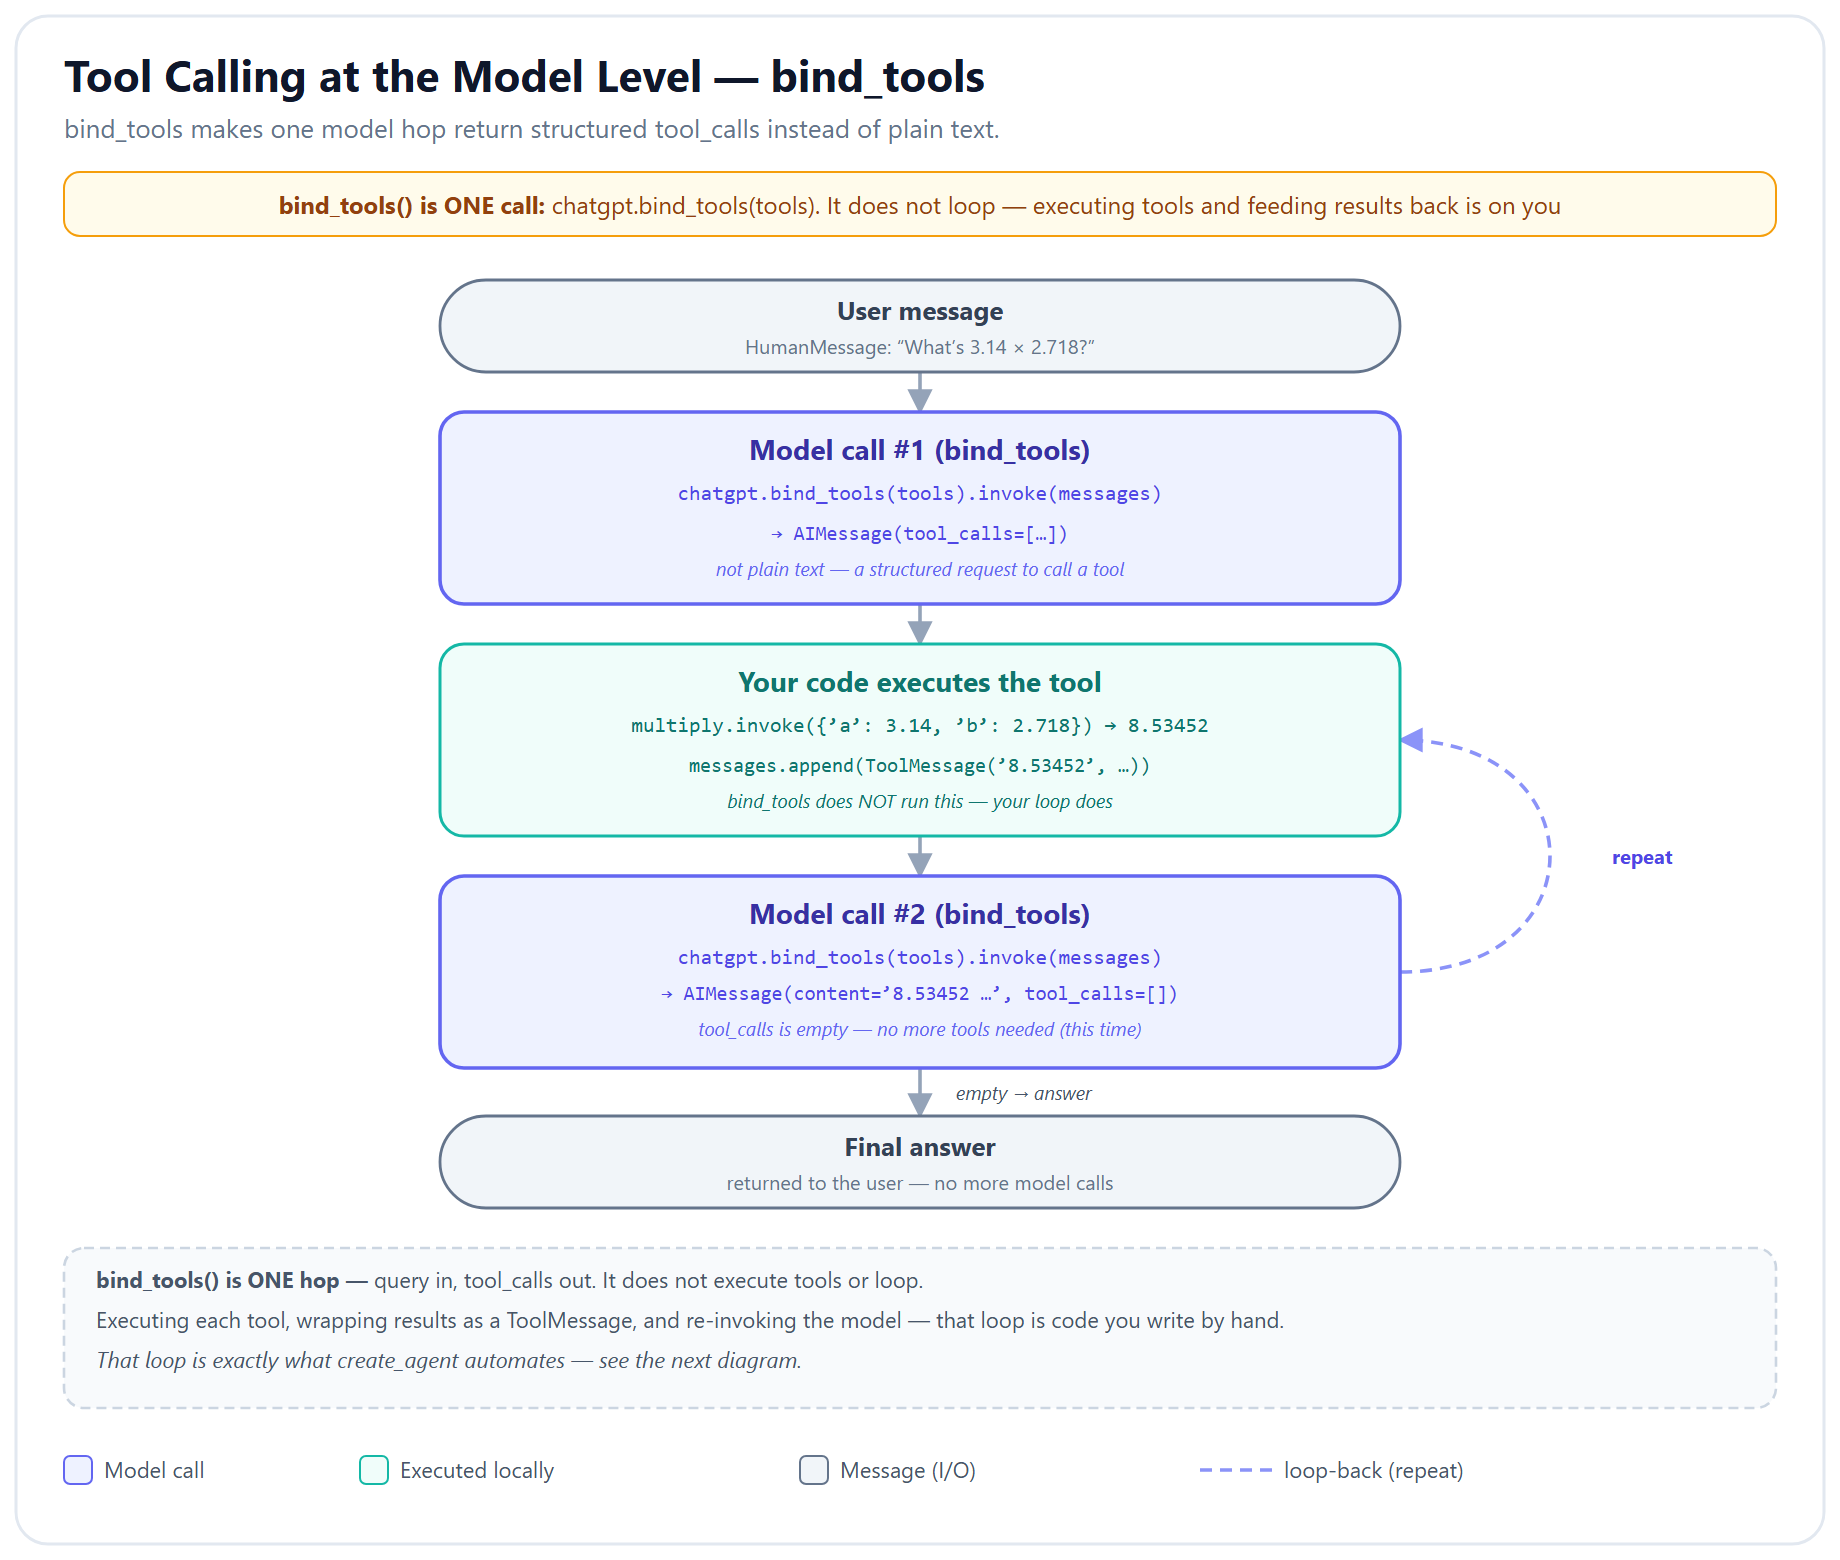

**Figure — Tool-calling at the model level (`bind_tools`).** `llm.bind_tools(tools)` makes the model emit a `tool_calls` list instead of text; you execute each call and feed a `ToolMessage` back. `bind_tools` does one hop — the loop around it is yours to write.

In [11]:
tools = [tavily_tool, multiply, get_weather]

# Bind the tool definitions to the model — the LLM now sees their schemas
chatgpt_with_tools = chatgpt.bind_tools(tools)

user_query = (
    'I need three things from you: '
    '(1) what is 3.14 times 2.718, '
    '(2) the current weather in Mumbai, and '
    '(3) the four major Agentic AI design patterns in 2026.'
)

result = chatgpt_with_tools.invoke(user_query)
print('Model output content (often empty when tools are called):')
print(repr(result.content))
print(f'\nTool calls planned by the model: {len(result.tool_calls)}')


Model output content (often empty when tools are called):
''

Tool calls planned by the model: 3


In [12]:
# Inspect each planned tool call
for tool_call in result.tool_calls:
    print(f'• Tool: {tool_call["name"]}')
    print(f'  Args: {tool_call["args"]}')
    print()


• Tool: multiply
  Args: {'first_number': 3.14, 'second_number': 2.718}

• Tool: get_weather
  Args: {'location': 'Mumbai'}

• Tool: tavily_search
  Args: {'query': 'four major Agentic AI design patterns in 2026', 'search_depth': 'advanced', 'time_range': 'year', 'topic': 'general'}



In [ ]:
# Execute the planned tool calls manually — by hand, without an agent loop
toolkit = {available_tool.name: available_tool for available_tool in tools}

for tool_call in result.tool_calls:
    selected_tool = toolkit[tool_call['name']]
    print(f'Calling {tool_call["name"]}({tool_call["args"]})...')
    output = selected_tool.invoke(tool_call['args'])
    output_text = str(output)
    print(f'  → {output_text[:200]}{"..." if len(output_text) > 200 else ""}')
    print()


### Provider-portable tool-calling — the same tools on Groq

Tool-calling isn't OpenAI-specific. The **same tool objects** work with any provider that supports native tool-calling. Here we bind the identical `tools` list to a **Groq**-hosted Qwen3.8 27B model and watch it plan the same calls — the tool *schemas* are portable; only the model backend changes.

In [14]:
from langchain_groq import ChatGroq

# Same tools, different provider — a Groq-hosted Qwen3.8 27B model (needs GROQ_API_KEY).
groq_model = ChatGroq(model='qwen/qwen3.8-27b', temperature=0)
groq_with_tools = groq_model.bind_tools(tools)

groq_result = groq_with_tools.invoke(user_query)
print('Groq model:', groq_model.model_name)
print(f'Tool calls planned by Groq: {len(groq_result.tool_calls)}')
for tool_call in groq_result.tool_calls:
    print(f'  • {tool_call["name"]}({tool_call["args"]})')
print('\n👉 Same tool schemas, different backend — tool-calling is provider-portable.')

Groq model: qwen/qwen3.8-27b
Tool calls planned by Groq: 3
  • multiply({'first_number': 3.14, 'second_number': 2.718})
  • get_weather({'location': 'Mumbai'})
  • tavily_search({'query': 'four major Agentic AI design patterns 2026', 'search_depth': None})

👉 Same tool schemas, different backend — tool-calling is provider-portable.


### 📝 What the manual loop is missing

The cells above stop at "call the tools". They don't:
- Feed the tool *outputs* back to the model so it can produce a final user-facing answer.
- Handle the case where the model wants to call MORE tools after seeing the first batch's results.
- Limit iterations or detect tool-call loops.
- Stream events for a UI.

That's exactly what **`create_agent` (LangChain v1)** does for you.


### 🔁 The pattern with a name: **ReAct** (Reason → Act → Observe)

What the manual loop above is reaching for is the **ReAct** pattern — the agent **reasons** about what it needs, **acts** by calling a tool, **observes** the result, and loops until it can answer:

> **Reason** *(“I need to multiply two numbers”)* → **Act** `multiply(3.14, 2.718)` → **Observe** `8.53…` → *(repeat for weather, then search)* → **Answer**.

Doing this by hand means writing the loop, feeding tool outputs back, capping iterations, and handling errors yourself. **`create_agent`** (next) runs this ReAct loop for you.

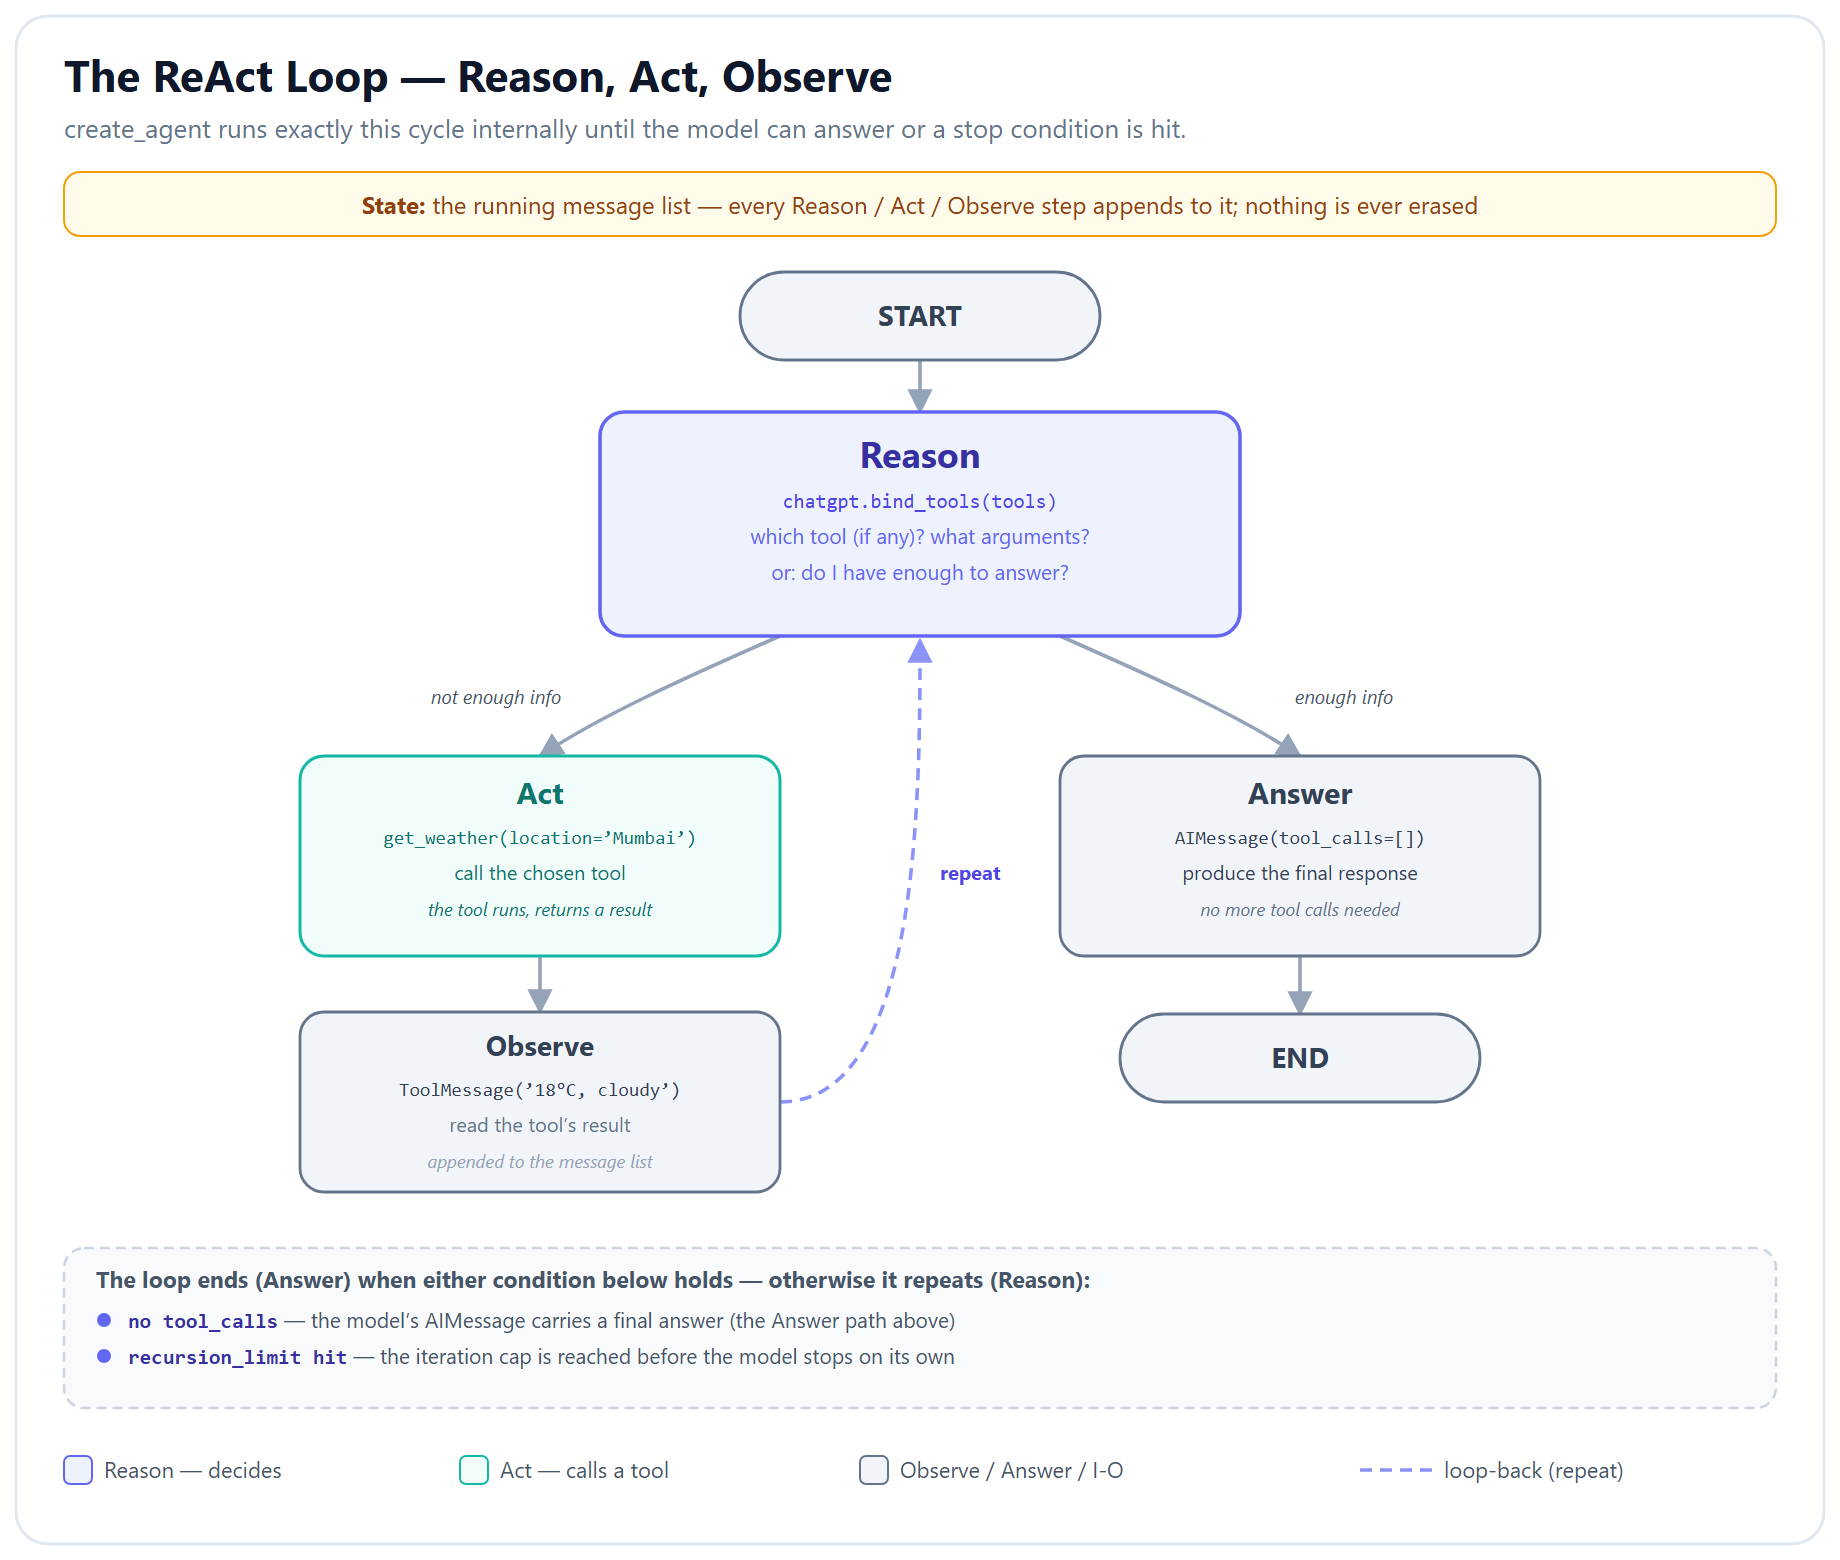

**Figure — The ReAct loop: Reason → Act → Observe.** The agent reasons about what it needs, acts by calling a tool, observes the result, and repeats — stopping on a final answer or an iteration cap. This is exactly the loop `create_agent` runs for you.

---
### 8b. Before native tool calling — classic ReAct by prompting ⭐ (stop sequences & parse errors)

Native tool calling (`bind_tools`) is recent. The first ReAct agents were **pure text**: the prompt
lists the tools and a strict *Thought → Action → Action Input → Observation* format, and your code
parses every reply. Two mechanics made that work — and both still explain agent failures today:

- **Stop sequences.** The model is told to stop generating at `\nObservation:`. Without it, the model
  happily writes the observation itself — an *invented* tool result — and carries on.
- **Parse errors.** Free text can break the format (no `Action Input`, invalid JSON). The loop must
  catch that and feed the error back as the observation, so the model can repair its reply.

The cell below runs this loop by hand — prompt, stop sequence, parser, tool call, observation — on
the multiplication question from §8.

In [15]:
import json
import re

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

# Classic ReAct is pure text: the prompt describes the tools and a strict format, and YOUR code
# parses each reply, runs the tool, and writes the Observation back.
react_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Answer the user's question. You can use these tools, one per step:\n"
     "{tool_descriptions}\n\n"
     "Reply in EXACTLY this format:\n"
     "Thought: what you need to do next\n"
     "Action: the tool to use — one of [{tool_names}]\n"
     "Action Input: the tool's arguments as a JSON object\n"
     "Observation: the tool's result (the system writes this line, never you)\n"
     "... Thought / Action / Action Input / Observation may repeat ...\n"
     "Thought: I now know the final answer\n"
     "Final Answer: the answer to the question"),
    ("human", "Question: {question}\n{scratchpad}"),
])

classic_tools = {"multiply": multiply, "get_weather": get_weather}
tool_descriptions = "\n".join(
    f"- {tool_name}: {tool_object.description} Arguments: {list(tool_object.args)}"
    for tool_name, tool_object in classic_tools.items())

# The STOP SEQUENCE: generation halts as soon as the model starts an "Observation:" line, so it can
# never invent a tool result — every observation comes from a real tool call.
react_step_chain = (
    react_prompt.partial(tool_descriptions=tool_descriptions, tool_names=", ".join(classic_tools))
    | chatgpt.bind(stop=["\nObservation:"])
    | StrOutputParser()
)

ACTION_PATTERN = re.compile(
    r"Action:\s*(?P<tool_name>[\w-]+)\s*Action Input:\s*(?P<tool_input>\{.*\})", re.DOTALL)


def parse_react_reply(model_text):
    """Parse one ReAct reply into ("final", answer) or ("action", tool_name, arguments).

    Raises:
        ValueError: the reply does not follow the format — a PARSE ERROR.
    """
    if "Final Answer:" in model_text:
        return ("final", model_text.split("Final Answer:")[-1].strip())
    action_match = ACTION_PATTERN.search(model_text)
    if action_match is None:
        raise ValueError("no 'Action:' / 'Action Input:' pair found")
    arguments = json.loads(action_match.group("tool_input"))   # bad JSON is a ValueError too
    return ("action", action_match.group("tool_name"), arguments)


def run_classic_react(question, max_steps=5):
    """Run the text-only ReAct loop: reply → parse → run the tool → append the Observation."""
    scratchpad = ""
    for step_number in range(1, max_steps + 1):
        model_text = react_step_chain.invoke({"question": question, "scratchpad": scratchpad})
        print(f"--- step {step_number} ---\n{model_text.strip()}")
        try:
            parsed_reply = parse_react_reply(model_text)
        except ValueError as parse_error:
            # Feed the parse error back as the observation, so the model can repair its format.
            observation = f"Invalid format: {parse_error}. Reply with an Action and Action Input."
        else:
            if parsed_reply[0] == "final":
                return parsed_reply[1]
            tool_name, arguments = parsed_reply[1], parsed_reply[2]
            if tool_name in classic_tools:
                observation = classic_tools[tool_name].invoke(arguments)
            else:
                observation = f"Unknown tool {tool_name!r} — choose one of {list(classic_tools)}."
        print(f"Observation: {observation}")
        scratchpad += f"{model_text.rstrip()}\nObservation: {observation}\n"
    return "Stopped: no final answer within the step limit."


final_answer = run_classic_react("What is 3.14 times 2.718?")
print(f"\nFinal answer: {final_answer}")

--- step 1 ---
Thought: I need to multiply 3.14 by 2.718 to find the answer.
Action: multiply
Action Input: {"first_number": 3.14, "second_number": 2.718}
Observation: 8.53452


--- step 2 ---
Thought: I now know the final answer
Final Answer: 3.14 times 2.718 is 8.53452.

Final answer: 3.14 times 2.718 is 8.53452.


In [16]:
# A PARSE ERROR — what the loop receives when a reply ignores the format (common with small models).
off_format_reply = "Thought: easy one.\nThe product is roughly 8.53, so no tool is needed."
try:
    parse_react_reply(off_format_reply)
except ValueError as parse_error:
    print(f"Parse error: {parse_error}")
    print("→ run_classic_react() sends this back as the Observation, and the model tries again.")

Parse error: no 'Action:' / 'Action Input:' pair found
→ run_classic_react() sends this back as the Observation, and the model tries again.


**What native tool calling changed.** The model now returns `tool_calls` as structured JSON beside
its text (§8), so there is no format to break, no regex to maintain and no stop sequence to set. The
loop is still ReAct — `create_agent` (next) runs it for you — only the transport moved from parsed
text to a structured field. When an agent misbehaves, you are still debugging this same loop.

---

## 9. The Modern Path — `create_agent` (LangChain v1)

Replaces the legacy `AgentExecutor` and the manual while-loop above. One function call gives you a runnable agent that:
1. Binds the tools to the LLM.
2. Runs the call → tool-execute → call-again loop until the model returns a final answer.
3. Caps iterations to prevent runaway loops.
4. Composes with `.invoke`, `.stream`, `.astream_events`, `.with_retry`, `.with_fallbacks` like any other Runnable.


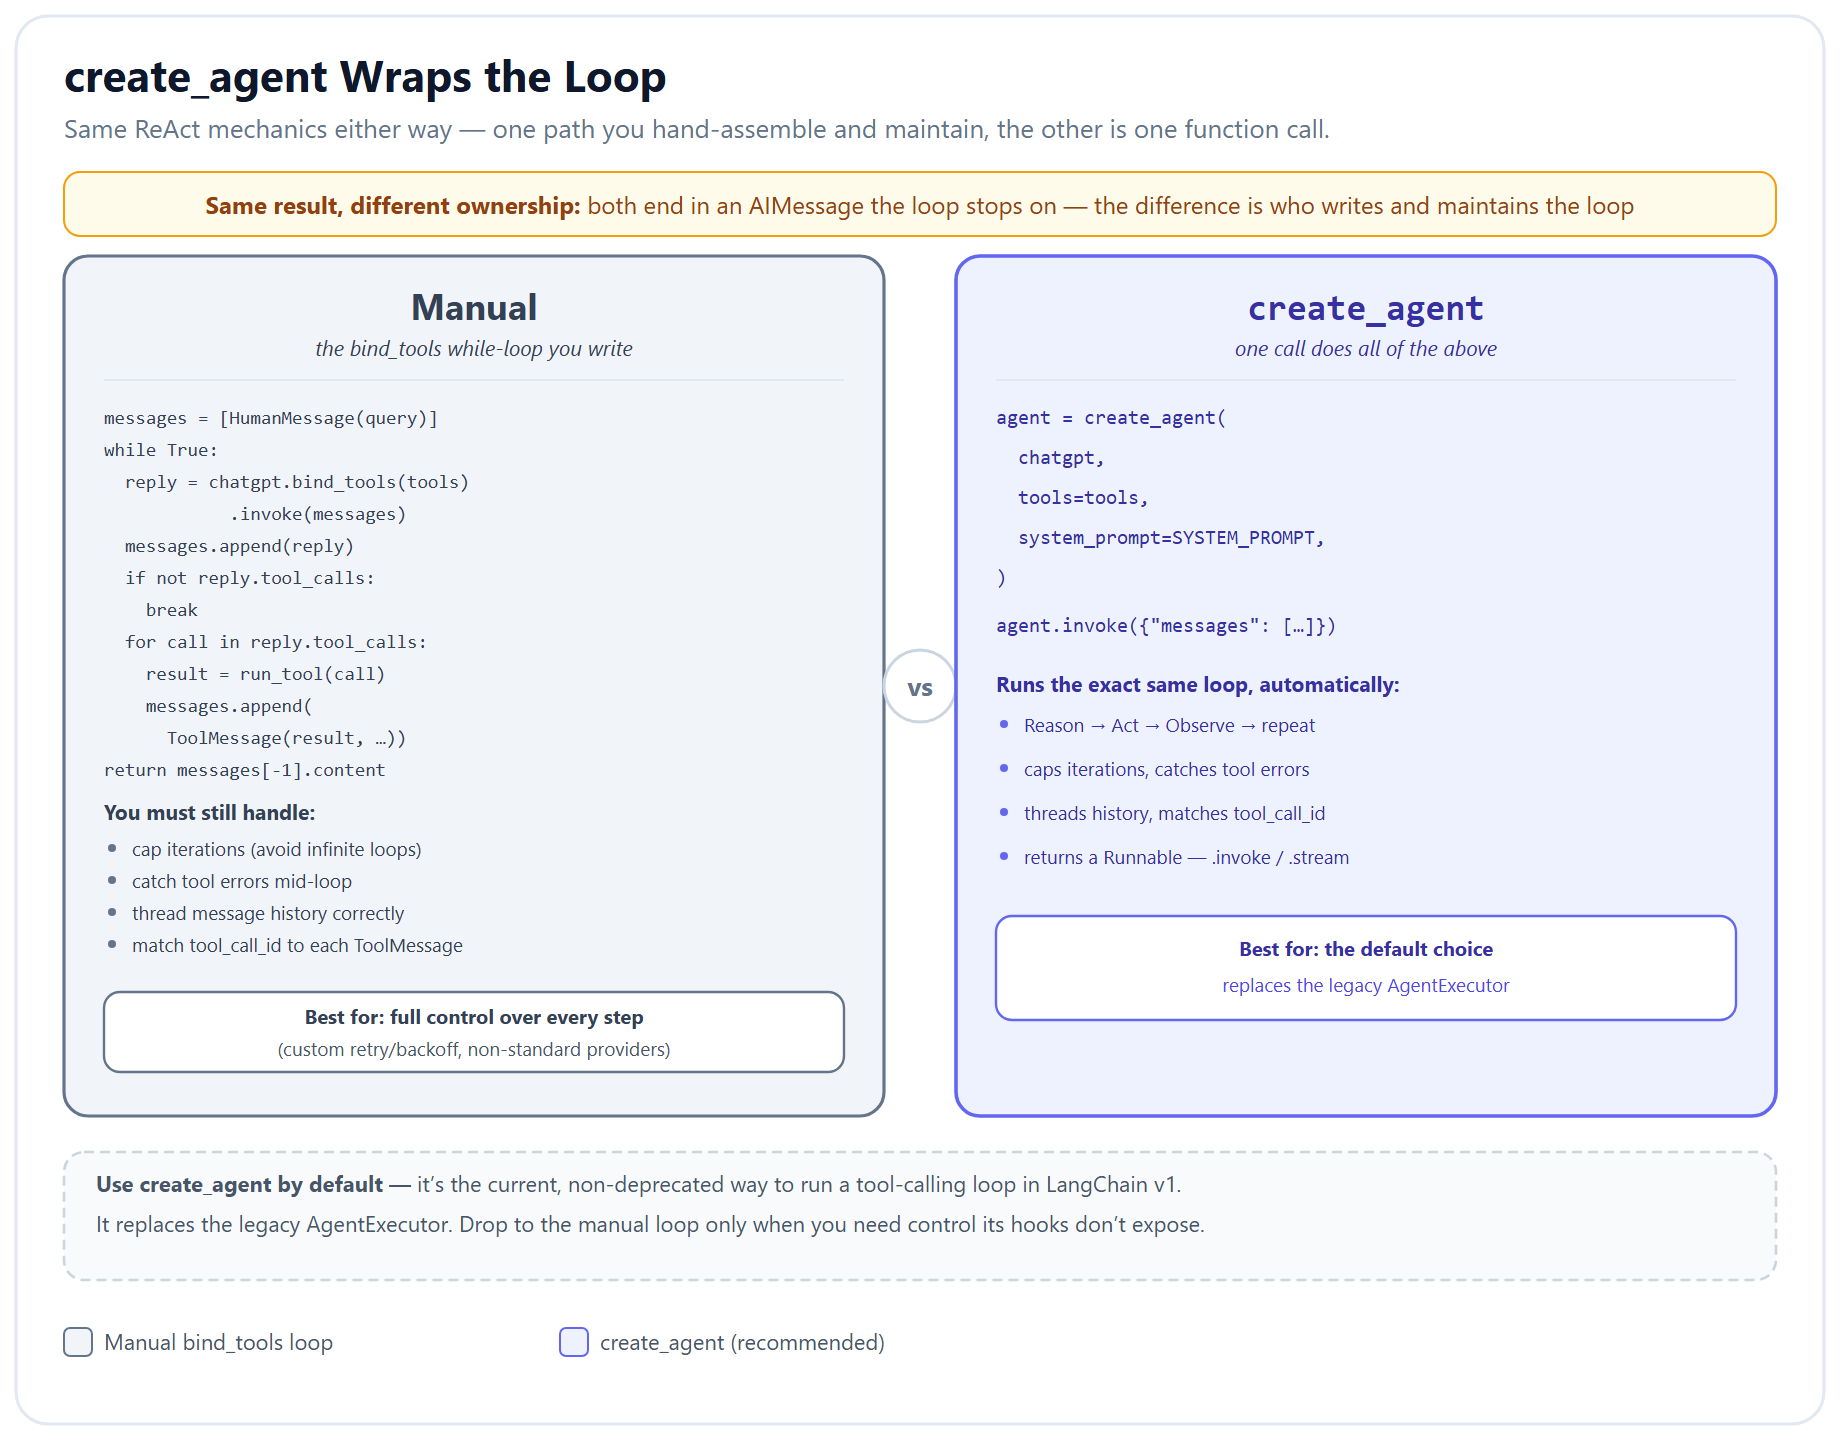

**Figure — `create_agent` wraps the loop.** What you'd hand-write as a `bind_tools` while-loop (call → execute → feed back → repeat → cap iterations → handle errors), `create_agent(model, tools, system_prompt)` returns as a single composable Runnable — replacing the legacy `AgentExecutor`.

In [17]:
from langchain.agents import create_agent

system_prompt = (
    'You are a helpful assistant with access to tools for math, weather lookups, and web search. '
    'Use tools when they help; otherwise answer directly. '
    'When you have all the information, give the user a clear, concise final answer.'
)

agent = create_agent(
    chatgpt,
    tools=tools,
    system_prompt=system_prompt,
)


In [ ]:
# Invoke — input is a list of messages (or a dict with 'messages' key)
result = agent.invoke({
    'messages': [
        {'role': 'user', 'content': user_query},
    ]
})

# The final assistant message is the user-facing answer
final = result['messages'][-1]
print('=== Final answer ===')
print(final.content)


In [ ]:
# Inspect every message in the conversation — system, user, tool calls, tool results, final answer
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage, SystemMessage

for position, message in enumerate(result['messages']):
    kind = type(message).__name__
    if isinstance(message, AIMessage) and message.tool_calls:
        print(f'{position}. [{kind}] tool_calls: {[tool_call["name"] for tool_call in message.tool_calls]}')
    elif isinstance(message, ToolMessage):
        preview = str(message.content)[:150]
        print(f'{position}. [{kind}] from {message.name}: {preview}{"..." if len(str(message.content)) > 150 else ""}')
    else:
        preview = str(message.content)[:150]
        print(f'{position}. [{kind}] {preview}{"..." if len(str(message.content)) > 150 else ""}')


---

## 10. Error Handling Inside an Agent Loop

What happens when a tool throws an exception? In LangChain v1, `create_agent` **lets it propagate — the run stops** — unless you add error-handling middleware: `ToolErrorMiddleware` will **catch the error and pass the message back to the model**, which then typically retries or asks the user for clarification. You can also customize this — you decide what text the model sees. (Arguments that fail the tool's schema are fed back to the model automatically.)


In [20]:
from langchain.agents.middleware import ToolErrorMiddleware

# A tool that always fails — to test error handling
@tool
def flaky_tool(query: str) -> str:
    """Use this tool to test error handling."""
    raise RuntimeError('flaky_tool intentionally failed')

def describe_tool_error(error, request):
    """Return the text the model sees when a tool raises — name the failure, keep internals out."""
    return f"Tool `{request.tool_call['name']}` failed ({type(error).__name__}). Continue without it."

agent_with_flaky = create_agent(
    chatgpt,
    tools=[flaky_tool, multiply],
    system_prompt='You are an assistant. If a tool fails, gracefully fall back to your own knowledge or ask the user.',
    # LangChain v1: without this middleware the RuntimeError would stop the whole run.
    middleware=[ToolErrorMiddleware(on_error=describe_tool_error)],
)

result = agent_with_flaky.invoke({
    'messages': [{'role': 'user', 'content': 'Use flaky_tool to look up something, then tell me 5 + 5.'}]
})
print(result['messages'][-1].content)


The tool to look up something failed, but I can still tell you that 5 + 5 is 10.


---

## 11. Debugging — When the Agent Picks the Wrong Tool

When an agent misbehaves, the diagnosis usually comes from **reading the tool descriptions and `args_schema`** as if you were the LLM:

1. Are tool names distinct and descriptive? (`multiply` is clearer than `do_thing`.)
2. Do docstrings explain *when* to use the tool, not just *what* it does?
3. Are `Field(description=...)` strings filled in?
4. Are there overlapping tools? (Two web-search tools confuse the model.)
5. Is the system prompt giving a clear policy on tool use?

Bumping the model from `gpt-4.1-mini` to `gpt-5-mini` (a reasoning model) often fixes ambiguous tool selection at higher latency cost.


---

## 🔭 Forward Reference: LangGraph (Module 7)

`create_agent` gives you a black-box loop that just works for ~80% of agentic use cases. When you need:
- **Explicit state** that survives across turns (typed via `TypedDict`)
- **Custom routing** between agent steps
- **Human-in-the-loop interrupts** mid-execution
- **Time-travel debugging** via checkpoints
- **Parallel sub-agents** (supervisor, swarm, hierarchical)

...you graduate to **LangGraph StateGraph** (Module 7). The same kind of agent is re-implemented there with explicit state management — a graph instead of a loop. First, Module 6 gives this same kind of agent a retriever, a database and web search.


---

## 12. Conclusion & Key Takeaways

| Concept | Walk-away |
|---|---|
| **Built-in tools** | LangChain ships with adapters (Tavily, Wikipedia, etc.) — drop-in, no setup |
| **`@tool` decorator** | Fastest way to define a custom tool — name, description, schema all derived from the function |
| **`StructuredTool` + Pydantic** | Use when you need explicit field descriptions or strict validation |
| **`bind_tools`** | Low-level — model produces a list of `tool_calls`; you execute them |
| **`create_agent` (LangChain v1)** | High-level — wraps the call→tool→call loop and caps iterations; add `ToolErrorMiddleware` so a failing tool becomes a message, not a crash |
| **Debugging tools** | Ambiguous tool selection usually = unclear name/description/`Field(description=...)` |

## 13. Stretch Exercise (Optional)
1. **Wikipedia tool back in.** Add `WikipediaQueryRun` from `langchain_community.tools` and observe how the agent picks Tavily vs Wikipedia for different query types.
2. **Iteration cap.** Set `max_iterations` (or wrap the agent with a manual counter) and force a query that requires more steps than the cap allows — observe the failure mode.
3. **Tool fallback.** Combine `.with_fallbacks()` to swap to a different model when the primary times out mid-tool-loop.
4. **Streaming events.** Use `agent.astream_events(...)` and print each `on_tool_start` / `on_tool_end` event as the agent runs.
5. **A second multiplier.** Add a `safe_multiply` tool that rejects negative numbers, then ask for `multiply(-3, 5)` — does the agent correctly pick the unsafe tool?
